In [58]:
#import các thư viện cần thiết
import pandas as pd
import os
import matplotlib.pyplot as plt

In [59]:
#lấy file csv
df = pd.read_csv("../data/Amazon-Products.csv", index_col=0)
df.head(3)

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255","₹32,999","₹58,990"
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948","₹46,490","₹75,990"
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206","₹34,490","₹61,990"


In [60]:
#kiểm tra xem có các giá trị NaN không
df.isnull().sum()

name                   0
main_category          0
sub_category           0
image                  0
link                   0
ratings           175794
no_of_ratings     175794
discount_price     61163
actual_price       17813
dtype: int64

In [61]:
print(df.shape[0])

551585


In [62]:
#xóa các giá trị NaN trong cột actual_price và discount_price
df = df.dropna(subset=["actual_price", "discount_price"])

In [63]:
print(df.shape[0])

490422


In [64]:
df[["actual_price", "discount_price"]].head(10)

,actual_price,discount_price
0,"₹58,990","₹32,999"
1,"₹75,990","₹46,490"
2,"₹61,990","₹34,490"
3,"₹68,990","₹37,990"
4,"₹67,790","₹34,490"
5,"₹70,990","₹31,990"
6,"₹49,990","₹29,999"
7,"₹67,990","₹39,990"
8,"₹58,190","₹30,990"
9,"₹73,990","₹37,999"


In [65]:
print(df["actual_price"].sample(10))

756        ₹299
16566    ₹3,999
13661      ₹510
2139       ₹599
18855      ₹899
1219     ₹7,595
11851    ₹4,999
2325     ₹1,199
14891      ₹799
7761     ₹1,999
Name: actual_price, dtype: str


In [66]:
#xóa kí tự tiền tệ và dấu phẩy, đưa dtype về float
for col in ["discount_price", "actual_price"]:
    df[col] = (
        df[col]
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

In [67]:
#chuyển giá trị sang VND
VND_RATE = 275.3

df["actual_price_vnd"] = df["actual_price"] * VND_RATE
df["discount_price_vnd"] = df["discount_price"] * VND_RATE

In [68]:
df.head(3)

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,actual_price_vnd,discount_price_vnd
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255",32999.00,58990.00,16239947.00,9084624.70
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948",46490.00,75990.00,20920047.00,12798697.00
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206",34490.00,61990.00,17065847.00,9495097.00


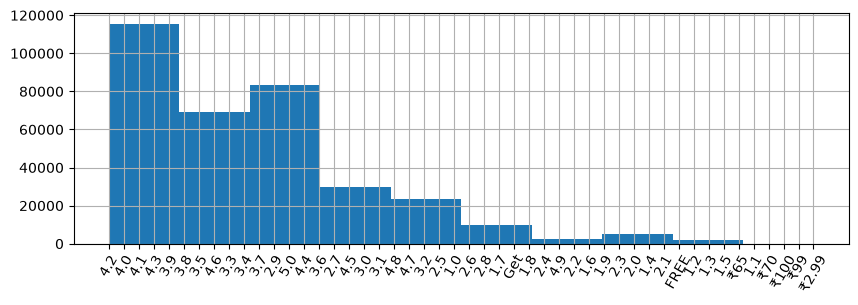

In [69]:
#trực quan hóa cột ratings
plt.figure(figsize=(10, 3))
plt.xticks(rotation=60)
df["ratings"].hist()
plt.show()

In [70]:
#lấy ra các kiểu giá trị của cột ratings
print(df["ratings"].unique())

<StringArray>
[  '4.2',   '4.0',   '4.1',   '4.3',   '3.9',   '3.8',   '3.5',     nan,
   '4.6',   '3.3',   '3.4',   '3.7',   '2.9',   '5.0',   '4.4',   '3.6',
   '2.7',   '4.5',   '3.0',   '3.1',   '4.8',   '4.7',   '3.2',   '2.5',
   '1.0',   '2.6',   '2.8',   '1.7',   'Get',   '1.8',   '2.4',   '4.9',
   '2.2',   '1.6',   '1.9',   '2.3',   '2.0',   '1.4',   '2.1',  'FREE',
   '1.2',   '1.3',   '1.5',   '₹65',   '1.1',   '₹70',  '₹100',   '₹99',
 '₹2.99']
Length: 49, dtype: str


In [71]:
#kiểm tra dtype cột ratings
df["ratings"].dtype

<StringDtype(storage='python', na_value=nan)>

In [72]:
#đưa dtype cột ratings về float64
df["ratings"] = pd.to_numeric(df["ratings"], errors="coerce")
df = df[(df["ratings"] >= 0) & (df["ratings"] <= 5)]
df["ratings"].dtype

dtype('float64')

In [73]:
category_rating = (
    df.groupby("main_category")["ratings"]
      .mean()
      .sort_values(ascending=False)
)

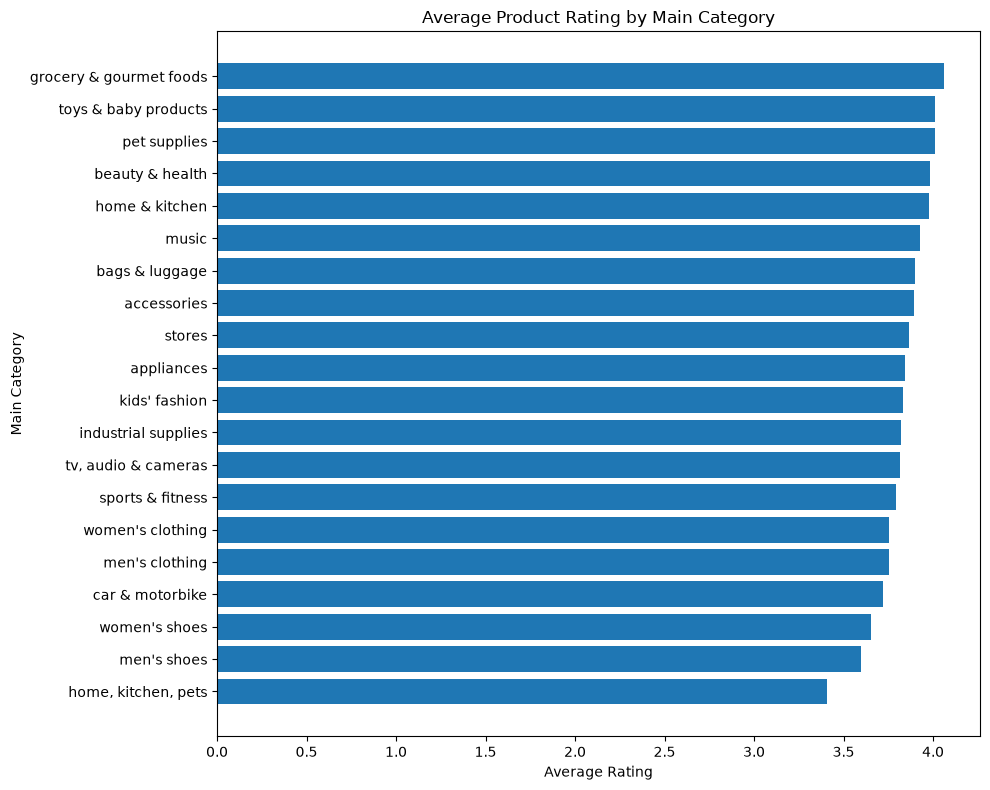

In [74]:
plt.figure(figsize=(10,8))

plt.barh(category_rating.index, category_rating.values)

plt.xlabel("Average Rating")
plt.ylabel("Main Category")
plt.title("Average Product Rating by Main Category")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

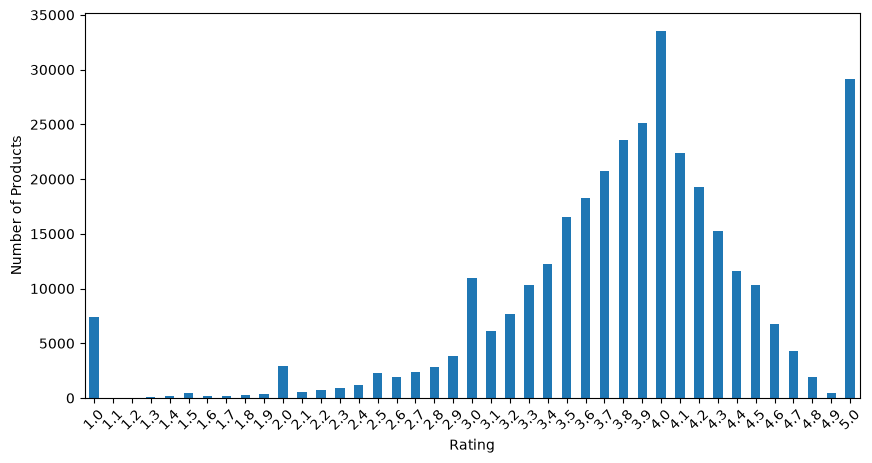

In [75]:
#trực quan hóa cột ratings
df_sorted = df.sort_values(by="ratings", ascending=True)

df_sorted[["name", "ratings"]].head(5)
rating_count = (
    df["ratings"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

rating_count.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

In [76]:
df.isnull().sum()

name                  0
main_category         0
sub_category          0
image                 0
link                  0
ratings               0
no_of_ratings         0
discount_price        0
actual_price          0
actual_price_vnd      0
discount_price_vnd    0
dtype: int64

In [77]:
print(df.shape[0])

334963


In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 334963 entries, 0 to 1103
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                334963 non-null  str    
 1   main_category       334963 non-null  str    
 2   sub_category        334963 non-null  str    
 3   image               334963 non-null  str    
 4   link                334963 non-null  str    
 5   ratings             334963 non-null  float64
 6   no_of_ratings       334963 non-null  str    
 7   discount_price      334963 non-null  float64
 8   actual_price        334963 non-null  float64
 9   actual_price_vnd    334963 non-null  float64
 10  discount_price_vnd  334963 non-null  float64
dtypes: float64(5), str(6)
memory usage: 30.7 MB


In [79]:
df["no_of_ratings"].head(10)

0    2,255
1    2,948
2    1,206
3       69
4      630
5    1,666
6    1,097
7    1,494
8      674
9      801
Name: no_of_ratings, dtype: str

In [80]:
text_columns = [
    "name",
    "main_category",
    "sub_category",
    "image",
    "link"
]


for col in text_columns:
    df[col] = df[col].astype("string")

In [81]:
df[text_columns].dtypes

name             string
main_category    string
sub_category     string
image            string
link             string
dtype: object

In [82]:
df["no_of_ratings"] = (
    df["no_of_ratings"]
    .astype(str)
    .str.replace(",", "")
)

In [83]:
df["no_of_ratings"] = pd.to_numeric(
    df["no_of_ratings"],
    errors="coerce"
)

In [84]:
df["no_of_ratings"] = df["no_of_ratings"].astype("int64")

In [85]:
df["no_of_ratings"].dtype

dtype('int64')

In [86]:
df["no_of_ratings"].head()

0    2255
1    2948
2    1206
3      69
4     630
Name: no_of_ratings, dtype: int64

In [87]:
df.info()

<class 'pandas.DataFrame'>
Index: 334963 entries, 0 to 1103
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                334963 non-null  string 
 1   main_category       334963 non-null  string 
 2   sub_category        334963 non-null  string 
 3   image               334963 non-null  string 
 4   link                334963 non-null  string 
 5   ratings             334963 non-null  float64
 6   no_of_ratings       334963 non-null  int64  
 7   discount_price      334963 non-null  float64
 8   actual_price        334963 non-null  float64
 9   actual_price_vnd    334963 non-null  float64
 10  discount_price_vnd  334963 non-null  float64
dtypes: float64(5), int64(1), string(5)
memory usage: 30.7 MB


In [88]:
df["discount_percent"] = (
    (df["actual_price_vnd"] - df["discount_price_vnd"])
    / df["actual_price_vnd"] * 100
).round(2)

In [89]:
pd.set_option("display.float_format", "{:.2f}".format)

In [90]:
df[["actual_price_vnd", "discount_price_vnd", "discount_percent"]].describe()

,actual_price_vnd,discount_price_vnd,discount_percent
count,334963.00,334963.00,334963.00
mean,9081746.66,484255.28,50.95
std,4709243693.36,1760399.52,21.47
min,2753.00,2202.40,0.00
25%,247770.00,98832.70,36.44
50%,412674.70,164904.70,53.07
75%,770564.70,330084.70,67.97
max,2725469999724.70,344122247.00,100.00


In [91]:
df.nlargest(10, "actual_price_vnd")[[
    "name", "actual_price", "actual_price",
    "actual_price_vnd",
    "discount_price_vnd"
]]

,name,actual_price,actual_price,actual_price_vnd,discount_price_vnd
853,"Marutivilla Insect Killer, Mosquito Killer Lig...",9899999999.00,9899999999.00,2725469999724.70,162151.70
351,Clovia Women's Activewear Ankle Length Printed...,61082990.00,61082990.00,16816147147.00,189406.40
584,Samsung 214 cm (85 inches) 8K Ultra HD Smart N...,1594900.00,1594900.00,439075970.00,344122247.00
886,Sri Jagdamba Pearls 10 Gm 24kt (999) Yellow Go...,700300.00,700300.00,192792590.00,18253766.50
373,Sony Bravia 195 cm (77 inches) XR Series 4K Ul...,699900.00,699900.00,192682470.00,125534047.00
577,Samsung 189 cm (75 inches) 4K Ultra HD Smart N...,589900.00,589900.00,162399470.00,112870247.00
380,Sony Bravia 164 cm (65 inches) XR Series 4K Ul...,479900.00,479900.00,132116470.00,88919147.00
559,Samsung 189 cm (75 inches) The Frame Series 4K...,424900.00,424900.00,116974970.00,81210747.00
589,LG 190.5 cm (75 inches) 75SK8000PTA 4K Super U...,419990.00,419990.00,115623247.00,80548650.50
3396,Canon EOS 5D Mark IV 30.4 MP Digital SLR Camer...,412995.00,412995.00,113697523.50,102406094.00


In [92]:
df.nlargest(20, "actual_price_vnd")[["name", "actual_price_vnd"]]

,name,actual_price_vnd
853,"Marutivilla Insect Killer, Mosquito Killer Lig...",2725469999724.70
351,Clovia Women's Activewear Ankle Length Printed...,16816147147.00
584,Samsung 214 cm (85 inches) 8K Ultra HD Smart N...,439075970.00
886,Sri Jagdamba Pearls 10 Gm 24kt (999) Yellow Go...,192792590.00
373,Sony Bravia 195 cm (77 inches) XR Series 4K Ul...,192682470.00
577,Samsung 189 cm (75 inches) 4K Ultra HD Smart N...,162399470.00
380,Sony Bravia 164 cm (65 inches) XR Series 4K Ul...,132116470.00
559,Samsung 189 cm (75 inches) The Frame Series 4K...,116974970.00
589,LG 190.5 cm (75 inches) 75SK8000PTA 4K Super U...,115623247.00
3396,Canon EOS 5D Mark IV 30.4 MP Digital SLR Camer...,113697523.50


In [93]:
df = df[
    (df["actual_price_vnd"] < 1_000_000_000) &
    (df["discount_price_vnd"] < 1_000_000_000)
]

In [94]:
df.nsmallest(20, "actual_price_vnd")[["name", "actual_price_vnd"]]

,name,actual_price_vnd
828,"Bingo! Tedhe Medhe Masala Tadka, 50g, Spindle ...",2753.00
849,"BRU Instant Coffee Sachet,Ground, 8g",2753.00
291,Rin Detergent Bar - 165g,2753.00
17,"Kurkure Yummy Cheese Puffcorn Namkeen, 28g",2753.00
21,"Lay's Potato Chips 24g/27g, West Indies Hot 'n...",2753.00
333,"Cadbury Oreo Original Vanilla Creme Biscuit, 4...",2753.00
177,"Saffola Masala Oats, Classic Masala, 39g",4129.50
201,Good Knight Advanced Fast Card - 10 Cards Pack,4129.50
593,"Too Yumm! Multigrain Chips, Dahi Papdi Chaat, 54g",5506.00
140,"Tropicana Litchi Delight Tetra Fruit Juice, 200ml",5506.00


In [95]:
df["actual_price_vnd"].quantile([0.000015, 0.01, 0.05, 0.95, 0.99])

0.00       2786.59
0.01      60566.00
0.05     109844.70
0.95    2725470.00
0.99   10206196.90
Name: actual_price_vnd, dtype: float64

In [96]:
def price_range(price):
    if price < 100_000:
        return "Budget"
    elif price < 500_000:
        return "Low"
    elif price < 2_000_000:
        return "Medium"
    elif price < 10_000_000:
        return "High"
    else:
        return "Premium"

df["price_range"] = df["actual_price_vnd"].apply(price_range)

In [97]:
df.to_csv(
    "../data/Amazon-Products_processed.csv",
    index=False
)